In [ ]:
import pandas as pd
import numpy as np

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pip install pandas numpy nltk scikit-learn matplotlib seaborn wordcloud

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [ ]:
df = pd.read_csv("/content/sentiment_analysis.csv")

In [ ]:
print(df.head())

   Year  Month  Day Time of Tweet  \
0  2018      8   18       morning   
1  2018      8   18          noon   
2  2017      8   18         night   
3  2022      6    8       morning   
4  2022      6    8          noon   

                                                text sentiment     Platform  
0              What a great day!!! Looks like dream.  positive    Twitter    
1     I feel sorry, I miss you here in the sea beach  positive    Facebook   
2                                     Don't angry me  negative     Facebook  
3  We attend in the class just for listening teac...  negative    Facebook   
4                  Those who want to go, let them go  negative   Instagram   


In [ ]:
print(df.shape)

(499, 7)


In [ ]:
print(df.columns)

Index(['Year', 'Month', 'Day', 'Time of Tweet', 'text', 'sentiment',
       'Platform'],
      dtype='object')


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB
None


In [ ]:
print(df.isnull().sum())

Year             0
Month            0
Day              0
Time of Tweet    0
text             0
sentiment        0
Platform         0
dtype: int64


In [ ]:
print(df['sentiment'].value_counts())

sentiment
neutral     199
positive    166
negative    134
Name: count, dtype: int64


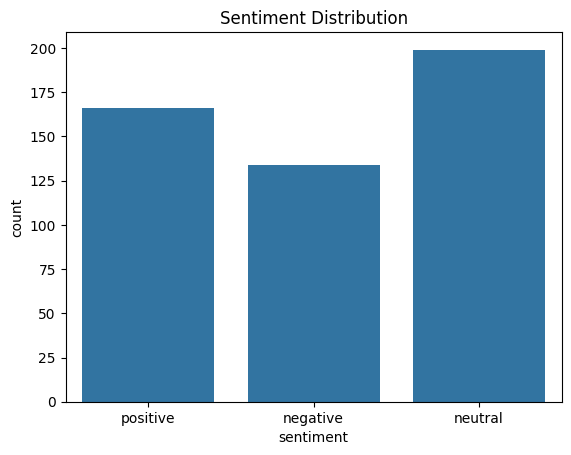

In [ ]:
sns.countplot(x='sentiment', data=df)

plt.title("Sentiment Distribution")

plt.show()

In [ ]:
print(df.tail(10))

     Year  Month  Day Time of Tweet  \
489  2021     11   30       morning   
490  2023      1   22          noon   
491  2023      1   24         night   
492  2023      1   27       morning   
493  2023      3    3          noon   
494  2015     10   18         night   
495  2021      2   25       morning   
496  2022      5   30          noon   
497  2018      8   10         night   
498  2019      3   25       morning   

                                                  text sentiment     Platform  
489                              thats another sponsor   neutral   Instagram   
490   And most of us are going to be stuck in an of...  negative     Twitter   
491             No it`s not sad. Should make you proud  negative   Instagram   
492                  Sorry, we`ll try to keep it down.  negative    Facebook   
493                           is home alone.. Doing hw   neutral   Instagram   
494  According to , a quarter of families under six...  negative     Twitter   
495      t

In [ ]:
print(df.sample(5))

     Year  Month  Day Time of Tweet  \
72   2017     12   28       morning   
415  2016     12    5          noon   
120  2015     12   18          noon   
162  2023      7    9          noon   
358  2023      3   10          noon   

                                                  text sentiment     Platform  
72   2 am feedings for the baby are fun when he is ...  positive    Facebook   
415  My phone passed away yesterday.. He jumped off...  negative   Instagram   
120  Hey everyone, do you watch cricket match betwe...   neutral    Twitter    
162                         Do you know sign languages   neutral     Twitter   
358                  this is sooo crazy i have fever..  negative    Twitter    


In [ ]:
print((df['sentiment'] == 'positive').sum())

166


In [ ]:
import re

text = "What a great day!!!"

clean_text = re.sub('[^a-zA-Z]', ' ', text)

print(clean_text)

What a great day   


In [ ]:
sentence = "I love NLP"

tokens = sentence.split()

print(tokens)

['I', 'love', 'NLP']


In [ ]:
from nltk.corpus import stopwords

words = ['this', 'movie', 'is', 'good']

filtered_words = [
    word for word in words
    if word not in stopwords.words('english')
]

print(filtered_words)

['movie', 'good']


In [ ]:
from nltk.stem.porter import PorterStemmer

port_stem = PorterStemmer()

print(port_stem.stem("playing"))

play


In [ ]:
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
import re

port_stem = PorterStemmer()

def preprocess_text(content):

    # Remove special characters
    content = re.sub('[^a-zA-Z]', ' ', content)

    # Convert to lowercase
    content = content.lower()

    # Tokenization
    content = content.split()

    # Stopword removal + stemming
    content = [
        port_stem.stem(word)
        for word in content
        if not word in stopwords.words('english')
    ]

    # Join words
    content = ' '.join(content)

    return content

In [ ]:
df['clean_text'] = df['text'].apply(preprocess_text)

In [ ]:
print(df[['text', 'clean_text']].head())

                                                text  \
0              What a great day!!! Looks like dream.   
1     I feel sorry, I miss you here in the sea beach   
2                                     Don't angry me   
3  We attend in the class just for listening teac...   
4                  Those who want to go, let them go   

                                       clean_text  
0                       great day look like dream  
1                       feel sorri miss sea beach  
2                                           angri  
3  attend class listen teacher read slide nonsenc  
4                                  want go let go  


In [ ]:
print(preprocess_text("I am LOVING this product!!!"))

love product


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer()

In [ ]:
X = df['clean_text']

In [ ]:
y = df['sentiment']

In [ ]:
X = vectorizer.fit_transform(X)

In [ ]:
print(X.shape)

(499, 1137)


In [ ]:
print(vectorizer.vocabulary_)

{'great': 424, 'day': 249, 'look': 580, 'like': 565, 'dream': 291, 'feel': 359, 'sorri': 917, 'miss': 629, 'sea': 844, 'beach': 93, 'angri': 38, 'attend': 63, 'class': 198, 'listen': 569, 'teacher': 975, 'read': 791, 'slide': 888, 'nonsenc': 684, 'want': 1077, 'go': 410, 'let': 562, 'night': 679, 'neutral': 670, 'feed': 358, 'babi': 75, 'fun': 396, 'smile': 895, 'coo': 218, 'soooo': 913, 'high': 464, 'today': 1004, 'first': 372, 'time': 999, 'arriv': 57, 'boat': 122, 'amaz': 35, 'journey': 520, 'love': 586, 'someth': 906, 'mc': 607, 'rule': 828, 'realli': 797, 'song': 909, 'cardigan': 169, 'taylor': 972, 'swift': 955, 'sharpi': 860, 'run': 829, 'danger': 245, 'low': 587, 'ink': 496, 'music': 655, 'tonight': 1011, 'lost': 583, 'voic': 1070, 'alway': 34, 'somewher': 907, 'distrub': 278, 'care': 170, 'sick': 873, 'past': 729, 'come': 205, 'back': 77, 'home': 469, 'job': 515, 'good': 414, 'never': 671, 'fall': 348, 'found': 388, 'oh': 700, 'maya': 604, 'hope': 473, 'find': 368, 'soon': 911

In [ ]:
print(vectorizer.get_feature_names_out())

['aaaaaah' 'aaaaaw' 'aawww' ... 'youtub' 'yum' 'zero']


In [ ]:
print(X.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Input and output
X = df['clean_text']
y = df['sentiment']

# Create vectorizer
vectorizer = TfidfVectorizer()

# Transform text into vectors
X = vectorizer.fit_transform(X)

# Check shape
print(X.shape)

(499, 1137)


In [ ]:
print(X.shape)
print(y.shape)

(499, 1137)
(499,)


In [ ]:
sample = ["I love NLP", "NLP is amazing"]

vec = TfidfVectorizer()

X = vec.fit_transform(sample)

print(vec.get_feature_names_out())

print(X.toarray())

['amazing' 'is' 'love' 'nlp']
[[0.         0.         0.81480247 0.57973867]
 [0.6316672  0.6316672  0.         0.44943642]]


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
print(df.head())
print(df.columns)

   Year  Month  Day Time of Tweet  \
0  2018      8   18       morning   
1  2018      8   18          noon   
2  2017      8   18         night   
3  2022      6    8       morning   
4  2022      6    8          noon   

                                                text sentiment     Platform  \
0              What a great day!!! Looks like dream.  positive    Twitter     
1     I feel sorry, I miss you here in the sea beach  positive    Facebook    
2                                     Don't angry me  negative     Facebook   
3  We attend in the class just for listening teac...  negative    Facebook    
4                  Those who want to go, let them go  negative   Instagram    

                                       clean_text  
0                       great day look like dream  
1                       feel sorri miss sea beach  
2                                           angri  
3  attend class listen teacher read slide nonsenc  
4                                  want go

In [ ]:
print(type(X))
print(type(y))

print(len(y))

try:
    print(X.shape)
except:
    print(len(X))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'pandas.core.series.Series'>
499
(2, 4)


In [ ]:
print(df.columns)

Index(['Year', 'Month', 'Day', 'Time of Tweet', 'text', 'sentiment',
       'Platform', 'clean_text'],
      dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

print(X_train.shape)
print(X_test.shape)

(399, 1137)
(100, 1137)


In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
print("Model trained successfully")

Model trained successfully


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:10])

['neutral' 'negative' 'neutral' 'positive' 'positive' 'neutral' 'negative'
 'neutral' 'neutral' 'neutral']


In [ ]:
print(type(model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [ ]:
print(X_train.shape)
print(X_test.shape)

(399, 1137)
(100, 1137)


In [ ]:
print(y_test[:5])
print(y_pred[:5])

396    negative
223    negative
461     neutral
179    positive
413    positive
Name: sentiment, dtype: object
['neutral' 'negative' 'neutral' 'positive' 'positive']


In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.62


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12 15  4]
 [ 1 34  4]
 [ 3 11 16]]


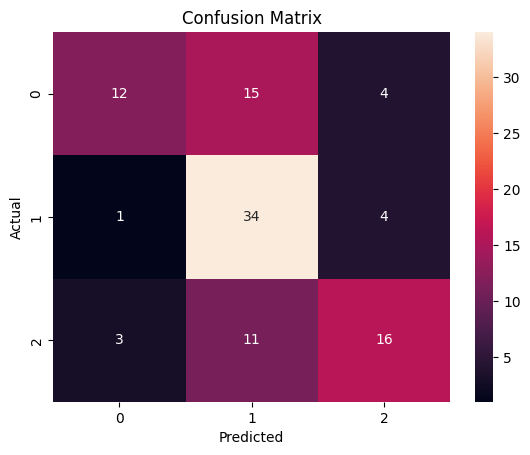

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.75      0.39      0.51        31
     neutral       0.57      0.87      0.69        39
    positive       0.67      0.53      0.59        30

    accuracy                           0.62       100
   macro avg       0.66      0.60      0.60       100
weighted avg       0.65      0.62      0.60       100



In [ ]:
print("Actual:")
print(y_test[:10])

print("Predicted:")
print(y_pred[:10])

Actual:
396    negative
223    negative
461     neutral
179    positive
413    positive
415    negative
1      positive
165     neutral
345     neutral
487     neutral
Name: sentiment, dtype: object
Predicted:
['neutral' 'negative' 'neutral' 'positive' 'positive' 'neutral' 'negative'
 'neutral' 'neutral' 'neutral']


In [ ]:
review = "This product is amazing and I love it"

review_clean = preprocess_text(review)

print(review_clean)

product amaz love


In [ ]:
review_vector = vectorizer.transform([review_clean])

In [ ]:
prediction = model.predict(review_vector)

print(prediction)

['positive']


In [ ]:
if prediction[0] == 'positive':
    print("😊 Positive Sentiment")
else:
    print("😞 Negative Sentiment")

😊 Positive Sentiment


In [ ]:
reviews = [
    "This product is amazing",
    "Worst service ever",
    "I love this phone",
    "Very disappointing experience"
]

for review in reviews:
    review_clean = preprocess_text(review)
    review_vector = vectorizer.transform([review_clean])
    prediction = model.predict(review_vector)

    print(f"Review: {review}")
    print(f"Sentiment: {prediction[0]}")
    print("-" * 40)

Review: This product is amazing
Sentiment: positive
----------------------------------------
Review: Worst service ever
Sentiment: neutral
----------------------------------------
Review: I love this phone
Sentiment: positive
----------------------------------------
Review: Very disappointing experience
Sentiment: neutral
----------------------------------------
